In [1]:
import sys
!{sys.executable} -m pip install -q torch matplotlib scikit-learn numpy

Training CBOW on 26 samples...
Epoch 50 | Loss: 1.5947
Epoch 100 | Loss: 0.9303
Epoch 150 | Loss: 0.5663
Epoch 200 | Loss: 0.3686


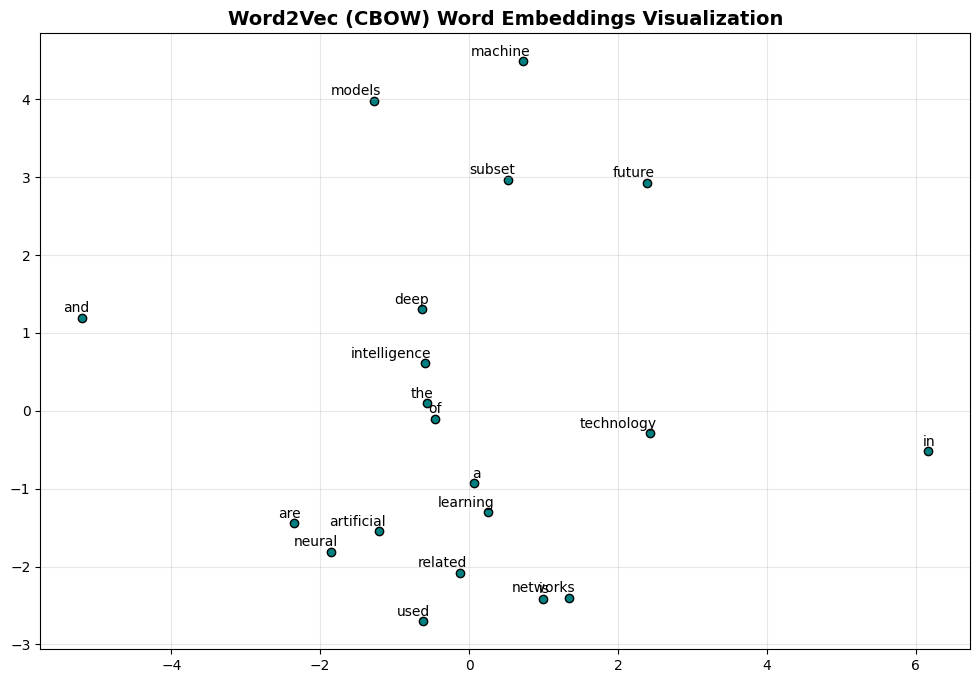


Sample Vector for 'learning':
[ 0.02766475 -0.6794913   0.96926135 -1.0203952  -0.12908415] ... (truncated)


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- 1. Data Preparation ---
corpus = """
deep learning is a subset of machine learning
artificial intelligence is the future of technology
neural networks are used in deep learning models
machine learning and artificial intelligence are related
"""

# Tokenization and Vocabulary
tokens = corpus.lower().split()
vocab = sorted(list(set(tokens)))
word_to_ix = {word: i for i, word in enumerate(vocab)}
ix_to_word = {i: word for i, word in enumerate(vocab)}
vocab_size = len(vocab)

# Create CBOW Training Pairs (Context_Words, Target_Word)
# Window size = 2 (2 words before, 2 words after)
data = []
for i in range(2, len(tokens) - 2):
    context = [
        tokens[i - 2], tokens[i - 1],
        tokens[i + 1], tokens[i + 2]
    ]
    target = tokens[i]
    data.append((context, target))

# --- 2. CBOW Model Architecture ---
class CBOW(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(CBOW, self).__init__()
        # The Embedding layer is our Word2Vec "Look-up Table"
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, vocab_size)

    def forward(self, inputs):
        # Embed the context words and take the average (Bag of Words)
        embeds = self.embeddings(inputs)
        add_embeds = torch.mean(embeds, dim=0).view(1, -1)
        out = self.linear(add_embeds)
        return out

# --- 3. Training ---
EMBEDDING_DIM = 20
model = CBOW(vocab_size, EMBEDDING_DIM)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

print(f"Training CBOW on {len(data)} samples...")
for epoch in range(200):
    total_loss = 0
    for context, target in data:
        # Convert words to indices and then to Tensors
        context_idxs = torch.tensor([word_to_ix[w] for w in context], dtype=torch.long)
        
        model.zero_grad()
        log_probs = model(context_idxs)
        
        loss = loss_function(log_probs, torch.tensor([word_to_ix[target]], dtype=torch.long))
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1} | Loss: {total_loss/len(data):.4f}")

# --- 4. Extracting and Visualizing Embeddings ---
# These weights ARE the word embeddings
word_vectors = model.embeddings.weight.data.numpy()

# Reduce to 2D using PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(word_vectors)

plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], c='teal', edgecolors='k')

for i, word in enumerate(vocab):
    plt.annotate(word, (coords[i, 0], coords[i, 1]), xytext=(5, 2), 
                 textcoords='offset points', ha='right', va='bottom', fontsize=10)

plt.title('Word2Vec (CBOW) Word Embeddings Visualization', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# --- 5. Semantic Check ---
def get_vector(word):
    return word_vectors[word_to_ix[word]]

print("\nSample Vector for 'learning':")
print(get_vector('learning')[:5], "... (truncated)")